## CMPE-257, Machine Learning, Summer 2025
## Week 2: Statistical Learning Theory

In this workbook, you will be exporing a simple regression problem:

- approximating an unknown function
- model complexity and learning
- sample complexity and learning
- exploring the effects of noise

In [1]:
# YOUR NAME: <enter your name here>

In [2]:
# Loading required modules
import random as rd
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib import pylab

## PART 1: Approximating an Unknown Function

In [3]:
# The following six functions provide the basis for the exporatory work you will be
# conducting in this coding session, study them and make sure you understand what they do

# GETGXVALS: computes g(x) for a given g() and set of x values
# GETFXVALS: computes f(x) = cos(x) for a given set of x values
# GETNOISE: computes noise (gaussian distribution, zero mean and specified variance)
# GETDATA: uses the three previos functions to compute a dataset and all associated values
# GETMSE: computes the mean square error between two lists of values
# GETOPTGX: finds the best fit (constant, linear, or quadratic) for a given set of points

# GETGXVALS: evaluates a given hypothesis gx over a set of provided data points xvals
# - gx: a list containing the coeficients of the model [a,...] -> a + b x + c x^2 + ...
# - xvals: a list of x values for which g(x) is to be computed
def getgxvals(gx,xvals):
    return [sum([r*x**i for i,r in enumerate(gx)]) for x in xvals]

# GETFXVALS: evaluates the generative funtion f(x)=cos(x) over a set of data points xvals
# - xvals: a list of x values for which f(x) is to be computed
def getfxvals(xvals):
    return [np.cos(x) for x in xvals]

# GETNOISE: produces random samples with gaussian distribution, zero mean and specified variance
# - vr: the desired variance value (float) for the resuting noise sequence
# - nspl: the desired number of random samples (int) in the resuting noise sequence
def getnoise(vr,nspl):
    tmp = [rd.gauss(0.0,vr**0.5) for x in range(nspl)]
    return [x-np.mean(tmp) for x in tmp]

# GETDATA: generates a dataset (dict) for experimental purposes. Input parameters include:
# - xvals: either the number of data points (int) or the specific x values to be used (list)
# - rnd: if TRUE, a random set of points is generated, if FALSE points are uniformly 
#   distributed between xmin and xman (if xvals is a list, rnd is ignored)
# - nvr: the desired variance for the additive noise component n -> y = f(x) + n
# - xmin: minimum value of x to be considered (if x values are generated, i.e. xvals is int)
# - xmax: maximum value of x to be considered (if x values are generated, i.e. xvals is int)
def getdata(xvals,rnd=False,nvr=0.0,xmin=0.0,xmax=4.55):
    if type(xvals) is list:
        ndata = len(xvals)
        xx = xvals
    elif rnd:
        ndata = int(xvals)
        xx = sorted([rd.uniform(xmin,xmax) for x in range(ndata)])
    else:
        ndata = int(xvals)
        xx = [(xmax-xmin)/ndata*t-xmin for t in range(ndata)]
    ff = getfxvals(xx)
    nn = getnoise(nvr,ndata)
    yy = [x+y for x,y in zip(ff,nn)]
    return {'x':xx,'f':ff,'n':nn,'y':yy,'nvar':nvr}

# GETMSE: computes de mean square error (MSE) between two lists of values
# - yvals: the set of values being evaluated
# - yrefs: the set of reference values to conduct the evaluation 
def getmse(yvals,yrefs):
    return sum([(yr-yv)**2 for yr,yv in zip(yrefs,yvals)])/len(yrefs)

# GETOPTGX: computes the optimal model (best fit) for a given set of data points
# - xvals: a list containing the x coordinates of the data points
# - yvals: a lits containing the y coordinates of the data points
# - order: the order of the model to be used (0: constant, 1: linear, 2: quadratic)
# Note 1: this function uses the closed solutions derived in class
# Note 2: models are returned as a list of coefficients, starting with the lowest order one
def getoptgx(xvals,yvals,order):
    ns = len(xvals)
    if order==0:
        k = sum(yvals)/len(yvals)
        gx = [k]
    elif order==1:
        sx = sum(xvals)
        sy = sum(yvals)
        sxy = sum([x*y for x,y in zip(xvals,yvals)])
        sx2 = sum([x**2 for x in xvals])
        m = (ns*sxy-sx*sy)/(ns*sx2-sx**2)
        b = (sy-m*sx)/ns
        gx = [b,m]
    elif order==2:
        sx = sum(xvals)
        sx2 = sum([x**2 for x in xvals])
        sx3 = sum([x**3 for x in xvals])
        sx4 = sum([x**4 for x in xvals])
        sy = sum(yvals)
        syx = sum([y*x for x,y in zip(xvals,yvals)])
        syx2 = sum([y*x**2 for x,y in zip(xvals,yvals)])
        bn = (ns*syx2-sy*sx2)*(ns*sx3-sx*sx2)-(ns*syx-sy*sx)*(ns*sx4-sx2**2)
        bd = (ns*sx3-sx*sx2)**2-(ns*sx2-sx**2)*(ns*sx4-sx2**2)
        b = bn/bd
        a = (ns*syx-sy*sx-b*(ns*sx2-sx**2))/(ns*sx3-sx*sx2)
        c = (sy-a*sx2-b*sx)/ns
        gx = [c,b,a]
    return gx

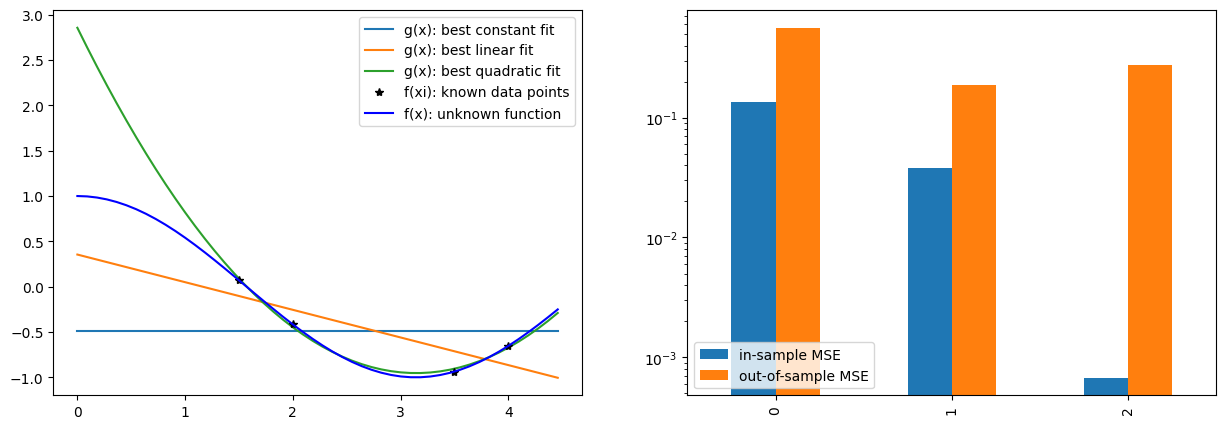

In [4]:
# Exercise #1: reproduce results presented in class for approximating an unknown f(X), 
# use the folowing values of x for the in-sample dataset [1.50,2.00,3.50,4.00], and
# consider three different model types: constant, linear, and quadratic 

fig, ax = plt.subplots(1,2,figsize=(15,5))
tags = ['constant','linear','quadratic']
results = []
models = []

in_sample_data = [1.50,2.00,3.50,4.00]

in_sample = getdata(in_sample_data)
out_sample = getdata(50)

for k in range(3):
    
    model = getoptgx(in_sample['x'],in_sample['y'],k)
    inmse = getmse(in_sample['y'],getgxvals(model,in_sample['x']))
    
    predictions = getgxvals(model,out_sample['x'])
    outmse = getmse(out_sample['y'],predictions)
    
    results.append({'Model Order':tags[k],'in-sample MSE':inmse,'out-of-sample MSE':outmse})
    models.append(model)

    ax[0].plot(out_sample['x'],predictions,label='g(x): best '+tags[k]+' fit')

ax[0].plot(in_sample['x'],in_sample['y'],'*k',label='f(xi): known data points')
ax[0].plot(out_sample['x'],out_sample['f'],'-b',label='f(x): unknown function')
ax[0].legend()

pd.DataFrame(results).plot(kind='bar',logy=True, ax=ax[1], legend=True)
pylab.legend(loc='lower left')
plt.show()

In [5]:
# Exercise 1 (continuation): display the obtained results in tabular form
display(pd.DataFrame(results).T)

,0,1,2
Model Order,constant,linear,quadratic
in-sample MSE,0.136458,0.037702,0.000675
out-of-sample MSE,0.562852,0.186096,0.275623


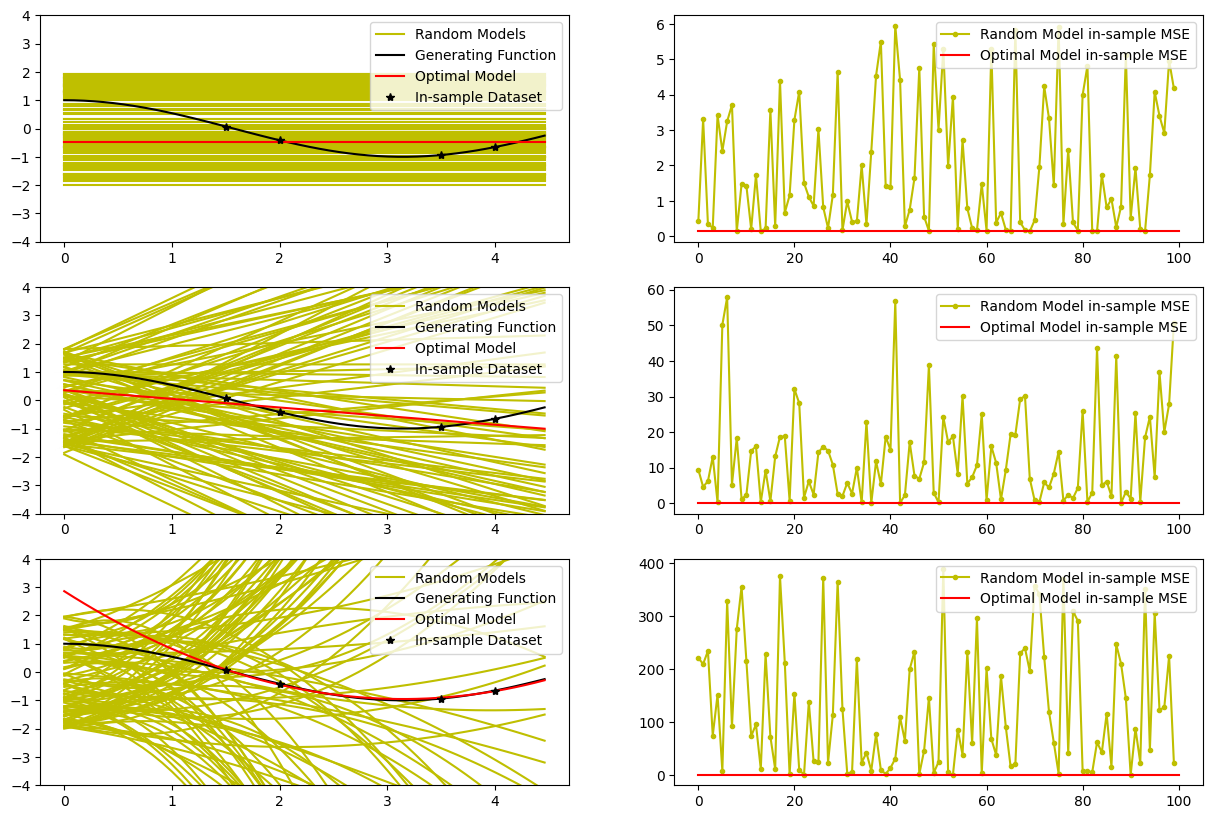

In [6]:
# Exercise #2: verify that the models obtained in exercise #1 are actually optimal fits 
# for the given in-sample dataset (Suggestion: for each of the three cases, generate ~100 
# random models and show the resulting MSE is always equal or greater than the MSE of the
# corresponding optimal model). Illustrate your results in a graph comparing the optimal
# fit error with respect to the randomly generated models' fit errors.

# add your code here...
fig, ax = plt.subplots(3,2,figsize=(15,10))

for morder in range(3):
    
    niters = []
    rerror = []
    maxiter = 100
    for n in range(maxiter):
        
        rmodel = [rd.uniform(-2,2) for x in range(morder+1)]
        rmodelerror = getmse(in_sample['y'],getgxvals(rmodel,in_sample['x']))
        rmodelpredictions = getgxvals(rmodel,out_sample['x'])
        niters.append(n)
        rerror.append(rmodelerror)
        
        if n==0:
            ax[morder,0].plot(out_sample['x'],rmodelpredictions,'-y',label='Random Models')
        else:
            ax[morder,0].plot(out_sample['x'],rmodelpredictions,'-y')
        
    ax[morder,0].plot(out_sample['x'],out_sample['f'],'-k',label='Generating Function')
    optpredictions = getgxvals(models[morder],out_sample['x'])
    ax[morder,0].plot(out_sample['x'],optpredictions,'-r',label='Optimal Model')
    ax[morder,0].plot(in_sample['x'],in_sample['y'],'*k',label='In-sample Dataset')
    ax[morder,0].set_ylim(-4.0,4.0)
    ax[morder,0].legend(loc='upper right')

    ax[morder,1].plot(niters,rerror,'.-y',label='Random Model in-sample MSE')
    opterror = getmse(in_sample['y'],getgxvals(models[morder],in_sample['x']))
    ax[morder,1].plot([0,maxiter],[opterror,opterror],'-r',label='Optimal Model in-sample MSE')
    ax[morder,1].legend(loc='upper right')

plt.show()

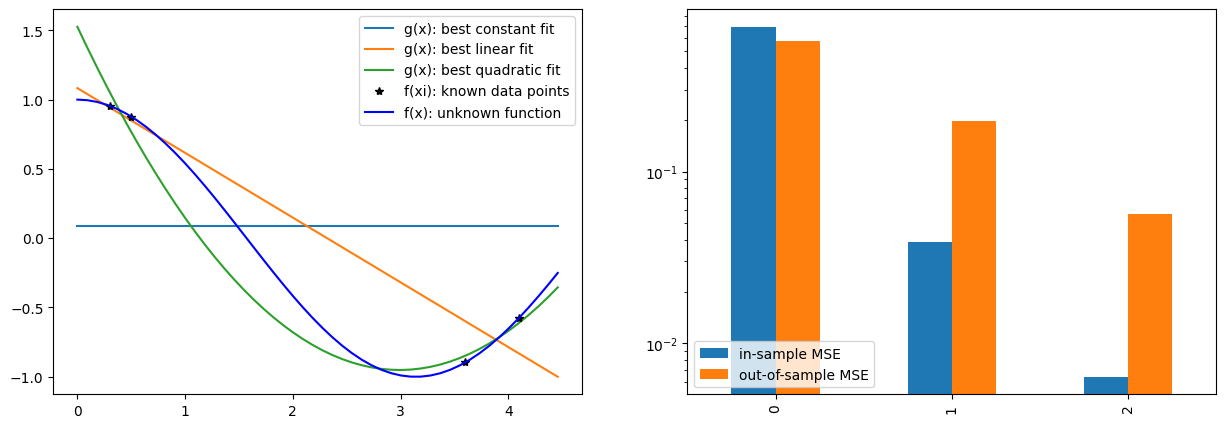

In [7]:
# Exercise #3: reproduce results from exercise #1 but, this time, find a different set of
# four in-sample data points such that the quadratic model exhibits the best out-of-sample MSE

# add your code here...
fig, ax = plt.subplots(1,2,figsize=(15,5))
results = []

in_sample_data = [0.3, 0.50,3.60,4.10] 

in_sample = getdata(in_sample_data)
out_sample = getdata(50)

for k in range(3):
    
    model = getoptgx(in_sample['x'],in_sample['y'],k)
    inmse = getmse(in_sample['y'],getgxvals(model,in_sample['x']))
    
    predictions = getgxvals(model,out_sample['x'])
    outmse = getmse(out_sample['y'],predictions)
    
    results.append({'Model Order':tags[k],'in-sample MSE':inmse,'out-of-sample MSE':outmse})

    ax[0].plot(out_sample['x'],predictions,label='g(x): best '+tags[k]+' fit')

ax[0].plot(in_sample['x'],in_sample['y'],'*k',label='f(xi): known data points')
ax[0].plot(out_sample['x'],out_sample['f'],'-b',label='f(x): unknown function')
ax[0].legend()

pd.DataFrame(results).plot(kind='bar',logy=True, ax=ax[1], legend=True)
pylab.legend(loc='lower left')
plt.show()

In [8]:
# Exercise #3 (continuation): display the obtained results in tabular form
display(pd.DataFrame(results).T)

,0,1,2
Model Order,constant,linear,quadratic
in-sample MSE,0.696194,0.039016,0.006393
out-of-sample MSE,0.572442,0.19639,0.05644


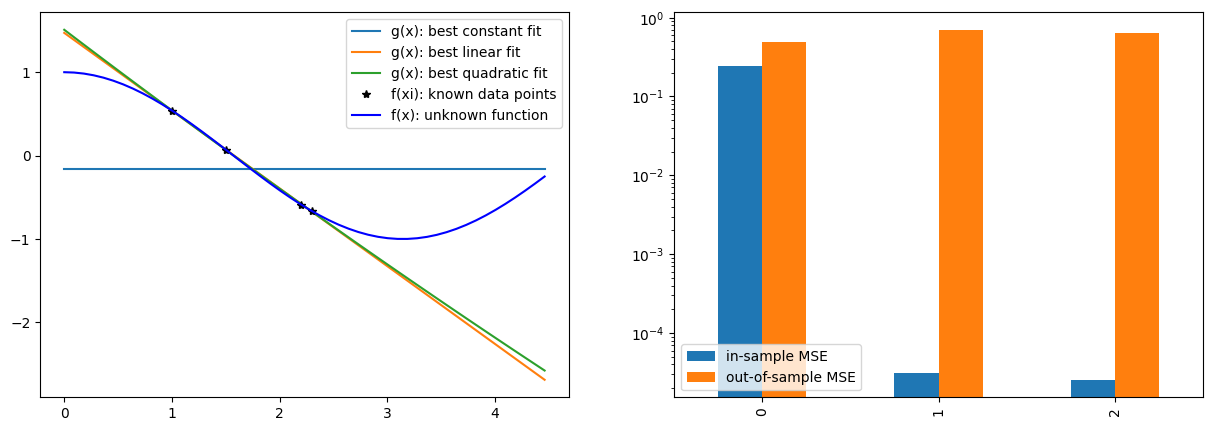

In [9]:
# Exercise #4: can you find a set of four in-sample data points such that the constant model
# exhibits the best out-of-sample MSE? If you succed in doing so, repeat exercises #3 here 
# for such in-sample dataset

# add your code here...
fig, ax = plt.subplots(1,2,figsize=(15,5))
results = []

in_sample_data = [1.0, 1.50,2.20,2.30] 

in_sample = getdata(in_sample_data)
out_sample = getdata(50)

for k in range(3):
    
    model = getoptgx(in_sample['x'],in_sample['y'],k)
    inmse = getmse(in_sample['y'],getgxvals(model,in_sample['x']))
    
    predictions = getgxvals(model,out_sample['x'])
    outmse = getmse(out_sample['y'],predictions)
    
    results.append({'Model Order':tags[k],'in-sample MSE':inmse,'out-of-sample MSE':outmse})

    ax[0].plot(out_sample['x'],predictions,label='g(x): best '+tags[k]+' fit')

ax[0].plot(in_sample['x'],in_sample['y'],'*k',label='f(xi): known data points')
ax[0].plot(out_sample['x'],out_sample['f'],'-b',label='f(x): unknown function')
ax[0].legend()

pd.DataFrame(results).plot(kind='bar',logy=True, ax=ax[1], legend=True)
pylab.legend(loc='lower left')
plt.show()

In [10]:
# Exercise #4 (continuation): display the obtained results in tabular form
display(pd.DataFrame(results).T)

,0,1,2
Model Order,constant,linear,quadratic
in-sample MSE,0.245897,0.000031,0.000026
out-of-sample MSE,0.4871,0.698859,0.637475


## PART 2: Model Complexity and Learning

In [11]:
# SIMULATIONS: this function allows you to run multiple simulations while varying certain 
# parameters, take a look at it and make sure you understand how it works
# - ind: the in-sample dataset (a dictionary as produced by GETDATA) If this input variable 
#   is not provided, a random in-sample dataset of size nsamples will be used
# - osd: the out-of-sample dataset (a dictionary as produced by GETDATA) If this input varable
#   is not provided, a uniformly distributed dataset of size 100 will be used
# - morder: a list containing the model orders to be considered (default value is [0,1,2])
# - nsamples: the size of the in-sample dataset (ignored if an in-sampled dataset is passed)
# - niter: the total number of iterations to be conducted per model type (notice this variable
#   value is overrited and made equal to 1 if an in-sample dataset is passed)
# - pflag: if TRUE, simulation plots are generated; if FALSE, no plot is generated

def simulations(ind={},osd={},morder=[0,1,2],nsamples=4,niter=1,pflag=False):
    
    if len(ind)>0:
        niter = 1
        rndflag = False
        nsamples = len(ind['x'])
    else:
        rndflag = True
    if len(osd)==0:
        osd = getdata(100)
    tags = ['constant','linear','quadratic']
    results = []

    if pflag: 
        fig, ax = plt.subplots(1,3,figsize=(15,5))

    for modelorder in morder:
        models = []
        in_mse = []
        out_mse = []
        all_predictions = []
    
        for k in tqdm(range(niter),desc=tags[modelorder].rjust(10)+'|'+str(nsamples).rjust(2)):
            
            if rndflag:
                ind=getdata(nsamples,rnd=True,nvr=osd['nvar'],xmin=osd['x'][0],xmax=osd['x'][-1])
                                    
            model = getoptgx(ind['x'],ind['y'],modelorder)
            in_mse.append(getmse(ind['y'],getgxvals(model,ind['x'])))
        
            predictions = getgxvals(model,osd['x'])
            out_mse.append(getmse(osd['y'],predictions))
            models.append(model)
        
            all_predictions.append(predictions)
    
        mean_model = np.array(models).mean(0)
        mean_predictions = getgxvals(mean_model,osd['x'])
    
        if pflag:
            for n,vals in enumerate(all_predictions[:50]):
                if n==0: ax[modelorder].plot(osd['x'],vals,'-y',label='Individual Models')
                else: ax[modelorder].plot(osd['x'],vals,'-y')
            ax[modelorder].plot(osd['x'],osd['f'],'-k',label='Generating Function')
            ax[modelorder].plot(osd['x'],osd['y'],'.k',label='Out-of-sample Data')
            ax[modelorder].plot(osd['x'],mean_predictions,'-r',label='Average Model')
            ax[modelorder].set_ylim(-4,4)
            ax[modelorder].legend(loc='upper right')

        results.append({'Model Order':modelorder,
                        'N Samples':nsamples,
                        'BIAS':getmse(osd['f'],mean_predictions),
                        'VAR':np.array(all_predictions).var(0).mean(),
                        'Noise':np.var(osd['n']),
                        'out_MSE':np.mean(out_mse),
                        'in_MSE':np.mean(in_mse)})
    
    tagseq = ['Model Order','N Samples','in_MSE','out_MSE','BIAS','VAR','Noise']
    return pd.DataFrame(results)[tagseq]

  constant| 4: 100%|█████████████████| 100000/100000 [00:03<00:00, 32479.96it/s]
    linear| 4: 100%|█████████████████| 100000/100000 [00:03<00:00, 27542.37it/s]
 quadratic| 4: 100%|█████████████████| 100000/100000 [00:04<00:00, 23553.54it/s]


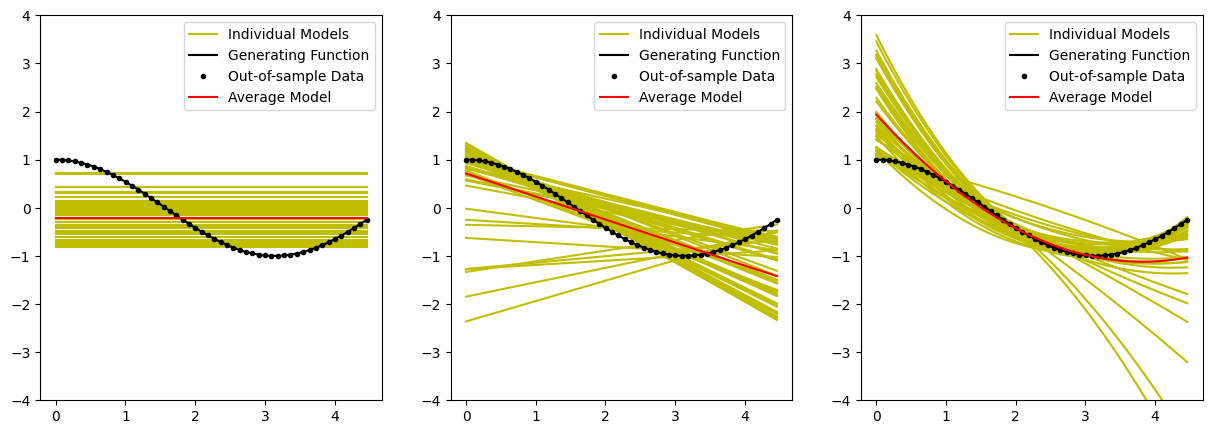

In [12]:
# Exercise #5: use the SIMULATIONS function above to compute average out-of-sample MSE, average 
# in-sample MSE, BIAS and VAR. Consider in-sample datasets of 4 points and an out-of-sample 
# dataset of 50 uniformly distributed points with zero noise variance. Run a large number (~100K) 
# of simulations for each model type (constant, linear, and quadratic). 

out_sample = getdata(50,nvr=0.0)
e5 = simulations(osd=out_sample,nsamples=4,niter=100000,pflag=True)

In [13]:
# Exercise #5 (continuation): add an additional column to the resulting dataframe with the
# sum of the BIAS, VAR and Noise columns; and another additional column containing the MSE
# between out-sample MSE and the newly computed BIAS+VAR+Noise. Display the dataframe.

# add your code here...
e5['B+V+N'] = e5[['BIAS','VAR','Noise']].sum(1)
e5['B+V+N_MSE'] = [getmse([x],[y]) for x, y in zip(e5['B+V+N'].values,e5['out_MSE'].values)]
display(e5)

,Model Order,N Samples,in_MSE,out_MSE,BIAS,VAR,Noise,B+V+N,B+V+N_MSE
0,0,4,0.360633,0.605288,0.485262,0.120026,0.0,0.605288,3.081488e-31
1,1,4,0.046082,0.375509,0.158760,0.216749,0.0,0.375509,6.240013e-30
2,2,4,0.002559,0.399926,0.112822,0.287104,0.0,0.399926,5.699520e-29


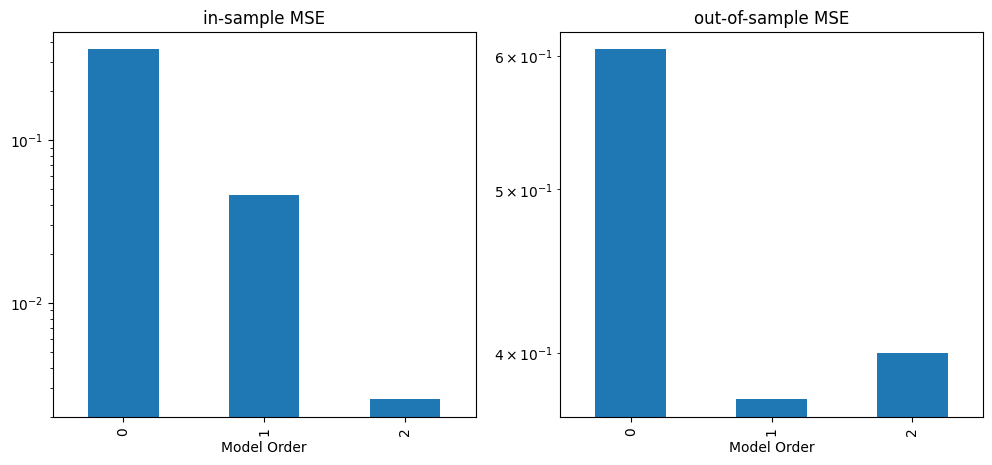

In [14]:
# Exercise #6: use the resuls from exercise #5 to generate MSE bar plots for the three models 
# under consideration. Depict the average in-sample MSEs in one bar plot and the average 
# out-of-sample MSEs in the second one. 

# add your code here...
fig,ax = plt.subplots(1,2,figsize=(12,5))
e5.set_index('Model Order')['in_MSE'].plot(kind='bar',logy=True,title='in-sample MSE',ax=ax[0])
e5.set_index('Model Order')['out_MSE'].plot(kind='bar',logy=True,title='out-of-sample MSE',ax=ax[1])
plt.show()

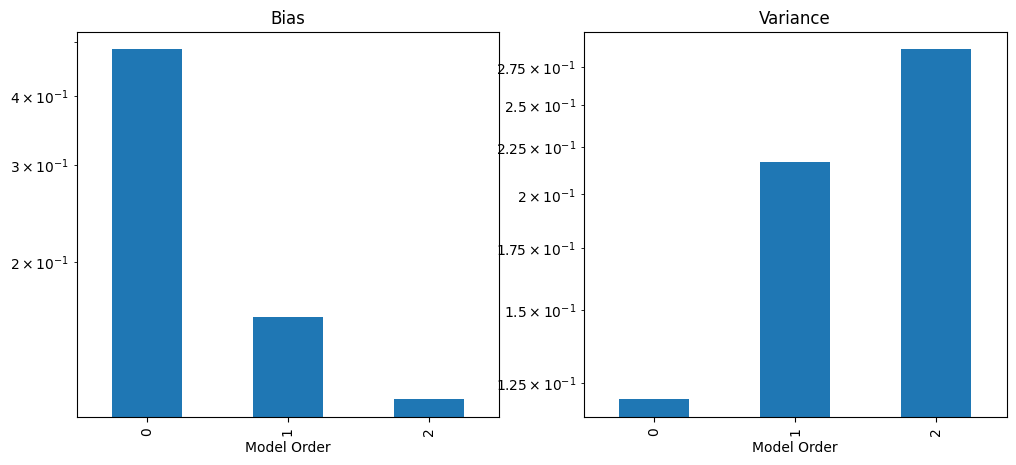

In [15]:
# Exercise #7: use the resuls from exercise #5 to generate MSE bar plots for the three models 
# under consideration. Depict the BIAS in one bar plot and the VAR in the second one. 

# add your code here...
fig,ax = plt.subplots(1,2,figsize=(12,5))
e5.set_index('Model Order')['BIAS'].plot(kind='bar',logy=True,title='Bias',ax=ax[0])
e5.set_index('Model Order')['VAR'].plot(kind='bar',logy=True,title='Variance',ax=ax[1])
plt.show()

## PART 3: Sample Complexity and Learning

In [16]:
# Exercise 8: implement a loop to conduct similar simulations to the ones in exercise #5
# while varying the nsample parameter (sugested values [3,4,5,6,7,8,9,10,12,15,20]). Consider 
# an out-of-sample dataset of 50 uniformly distributed points with zero noise variance. Again,
# run a large number (~100K) of simulations for each model type and in-sample dataset size.

# add your code here...
out_sample = getdata(50,nvr=0.0)
tmp = []
for nsmpl in [3,4,5,6,7,8,9,10,12,15,20]:
    tmp.append(simulations(osd=out_sample,nsamples=nsmpl,niter=100000))
e8 = pd.concat(tmp).sort_values(by=['Model Order','N Samples']).reset_index(drop=True)

  constant| 3: 100%|█████████████████| 100000/100000 [00:02<00:00, 36322.82it/s]
    linear| 3: 100%|█████████████████| 100000/100000 [00:03<00:00, 30558.56it/s]
 quadratic| 3: 100%|█████████████████| 100000/100000 [00:03<00:00, 25819.95it/s]
  constant| 4: 100%|█████████████████| 100000/100000 [00:03<00:00, 32367.25it/s]
    linear| 4: 100%|█████████████████| 100000/100000 [00:03<00:00, 27546.84it/s]
 quadratic| 4: 100%|█████████████████| 100000/100000 [00:04<00:00, 23302.44it/s]
  constant| 5: 100%|█████████████████| 100000/100000 [00:03<00:00, 28987.41it/s]
    linear| 5: 100%|█████████████████| 100000/100000 [00:04<00:00, 24481.63it/s]
 quadratic| 5: 100%|█████████████████| 100000/100000 [00:04<00:00, 21035.88it/s]
  constant| 6: 100%|█████████████████| 100000/100000 [00:04<00:00, 23943.78it/s]
    linear| 6: 100%|█████████████████| 100000/100000 [00:04<00:00, 22632.38it/s]
 quadratic| 6: 100%|█████████████████| 100000/100000 [00:05<00:00, 19235.65it/s]
  constant| 7: 100%|████████

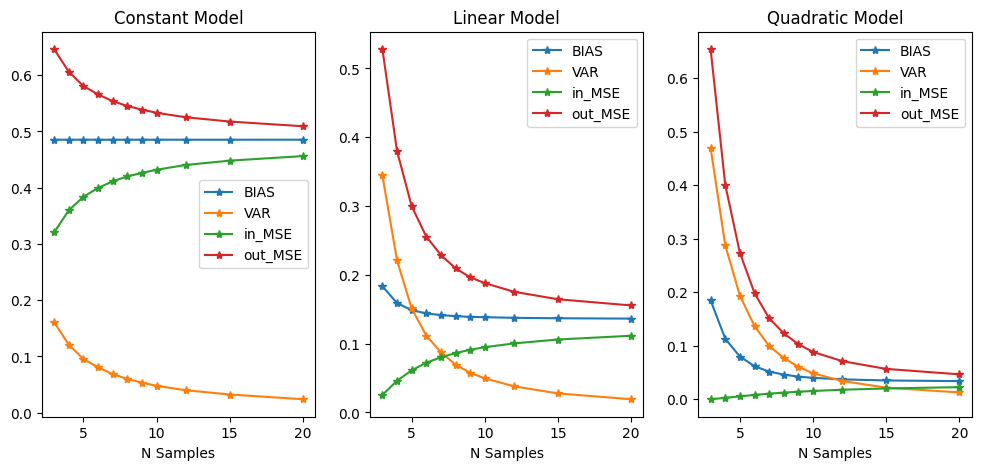

In [17]:
# Exercise 8 (continuation): generate three plots, one for each model type, displaying the
# resulting curves for average in-sample MSE, avergare out-of-sample MSE, BIAS and VAR as 
# a funtion of the nsamples parameter (i.e. the in-sample dataset size)

# add your code here...
fig,ax = plt.subplots(1,3,figsize=(12,5))
cols = ['BIAS','VAR','in_MSE','out_MSE']
for n in range(3):
    figttl = tags[n][0].upper()+tags[n][1:]+' Model'
    e8[e8['Model Order']==n].set_index('N Samples')[cols].plot(marker='*',ax=ax[n],title=figttl)
plt.show()

## PART 4: Exploring the Effects of Noise

  constant| 4: 100%|█████████████████| 100000/100000 [00:03<00:00, 31833.73it/s]
    linear| 4: 100%|█████████████████| 100000/100000 [00:03<00:00, 26727.49it/s]
 quadratic| 4: 100%|█████████████████| 100000/100000 [00:04<00:00, 22717.09it/s]


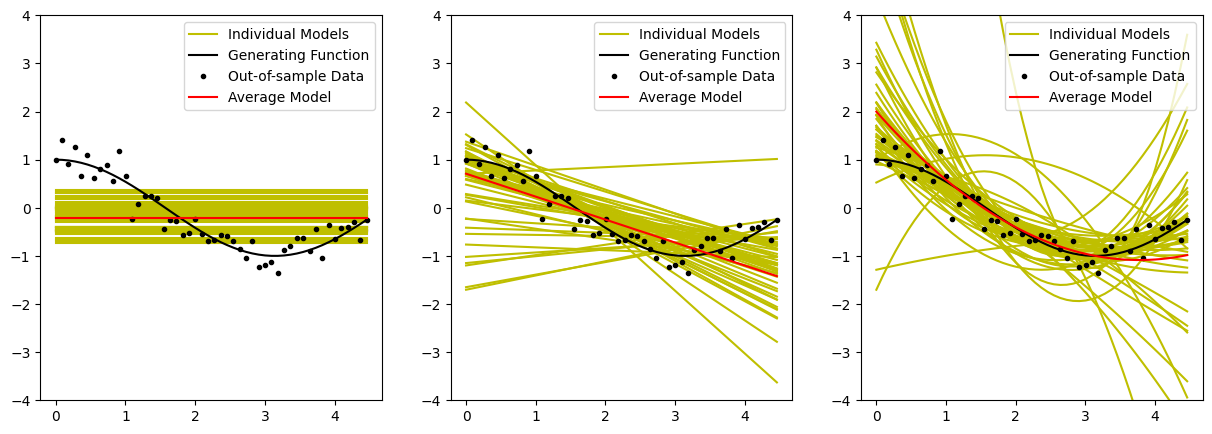

In [18]:
# Exercise #9: repat the simulation in exercise #5 but, this time, add noise with a variance 
# value of 0.05 to the generated data

# add your code here...
out_sample = getdata(50,nvr=0.05)
e9 = simulations(osd=out_sample,nsamples=4,niter=100000,pflag=True)

In [19]:
# Exercise #9 (continuation): add an additional column to the resulting dataframe with the
# sum of the BIAS, VAR and Noise columns; and another additional column containing the MSE
# between out-sample MSE and the newly computed BIAS+VAR+Noise. Display the dataframe.

# add your code here...
e9['B+V+N'] = e9[['BIAS','VAR','Noise']].sum(1)
e9['B+V+N_MSE'] = [getmse([x],[y]) for x, y in zip(e9['B+V+N'].values,e9['out_MSE'].values)]
display(e9)

,Model Order,N Samples,in_MSE,out_MSE,BIAS,VAR,Noise,B+V+N,B+V+N_MSE
0,0,4,0.397154,0.651389,0.485310,0.119779,0.059969,0.665058,0.000187
1,1,4,0.071560,0.505942,0.158953,0.276177,0.059969,0.495100,0.000118
2,2,4,0.015073,95.152429,0.114464,94.986850,0.059969,95.161284,0.000078


In [20]:
# Exercise #10: in theory, out_MSE = BIAS + VAR + var(Noise), can you explain the mismatch 
# observed in your results from exercise #9? If you come with an explanation for it, can you 
# run another simulation to verify your hypothesis?

# add your code here...
out_sample = getdata(1000,nvr=0.05)
e10 = simulations(osd=out_sample,nsamples=4,niter=100000)
e10['B+V+N'] = e10[['BIAS','VAR','Noise']].sum(1)
e10['B+V+N_MSE'] = [getmse([x],[y]) for x, y in zip(e10['B+V+N'].values,e10['out_MSE'].values)]
display(e10)

  constant| 4: 100%|██████████████████| 100000/100000 [00:31<00:00, 3189.12it/s]
    linear| 4: 100%|██████████████████| 100000/100000 [00:39<00:00, 2506.96it/s]
 quadratic| 4: 100%|██████████████████| 100000/100000 [00:49<00:00, 2040.22it/s]


,Model Order,N Samples,in_MSE,out_MSE,BIAS,VAR,Noise,B+V+N,B+V+N_MSE
0,0,4,0.391205,0.626612,0.471231,0.117448,0.049133,0.637811,0.000125
1,1,4,0.077449,0.520778,0.168415,0.308023,0.049133,0.525571,0.000023
2,2,4,0.015071,154.826045,0.130474,154.641150,0.049133,154.820757,0.000028


In [21]:
# Exercise #11: repeat exercise #8 but, again, adding noise with a variance value of 0.05;
# you can use a smaller set of nsamples values this time (sugested values [6,8,10,15,20]).

# add your code here...
out_sample = getdata(1000,nvr=0.05)
tmp = []
for nsmpl in [6,8,10,15,20]:
    tmp.append(simulations(osd=out_sample,nsamples=nsmpl,niter=100000))
e11 = pd.concat(tmp).sort_values(by=['Model Order','N Samples']).reset_index(drop=True)

  constant| 6: 100%|██████████████████| 100000/100000 [00:32<00:00, 3097.68it/s]
    linear| 6: 100%|██████████████████| 100000/100000 [00:41<00:00, 2426.52it/s]
 quadratic| 6: 100%|██████████████████| 100000/100000 [00:50<00:00, 1981.07it/s]
  constant| 8: 100%|██████████████████| 100000/100000 [00:33<00:00, 3026.70it/s]
    linear| 8: 100%|██████████████████| 100000/100000 [00:41<00:00, 2391.88it/s]
 quadratic| 8: 100%|██████████████████| 100000/100000 [00:51<00:00, 1940.41it/s]
  constant|10: 100%|██████████████████| 100000/100000 [00:34<00:00, 2922.88it/s]
    linear|10: 100%|██████████████████| 100000/100000 [00:43<00:00, 2307.91it/s]
 quadratic|10: 100%|██████████████████| 100000/100000 [00:53<00:00, 1882.40it/s]
  constant|15: 100%|██████████████████| 100000/100000 [00:37<00:00, 2695.59it/s]
    linear|15: 100%|██████████████████| 100000/100000 [00:45<00:00, 2177.24it/s]
 quadratic|15: 100%|██████████████████| 100000/100000 [00:55<00:00, 1805.74it/s]
  constant|20: 100%|████████

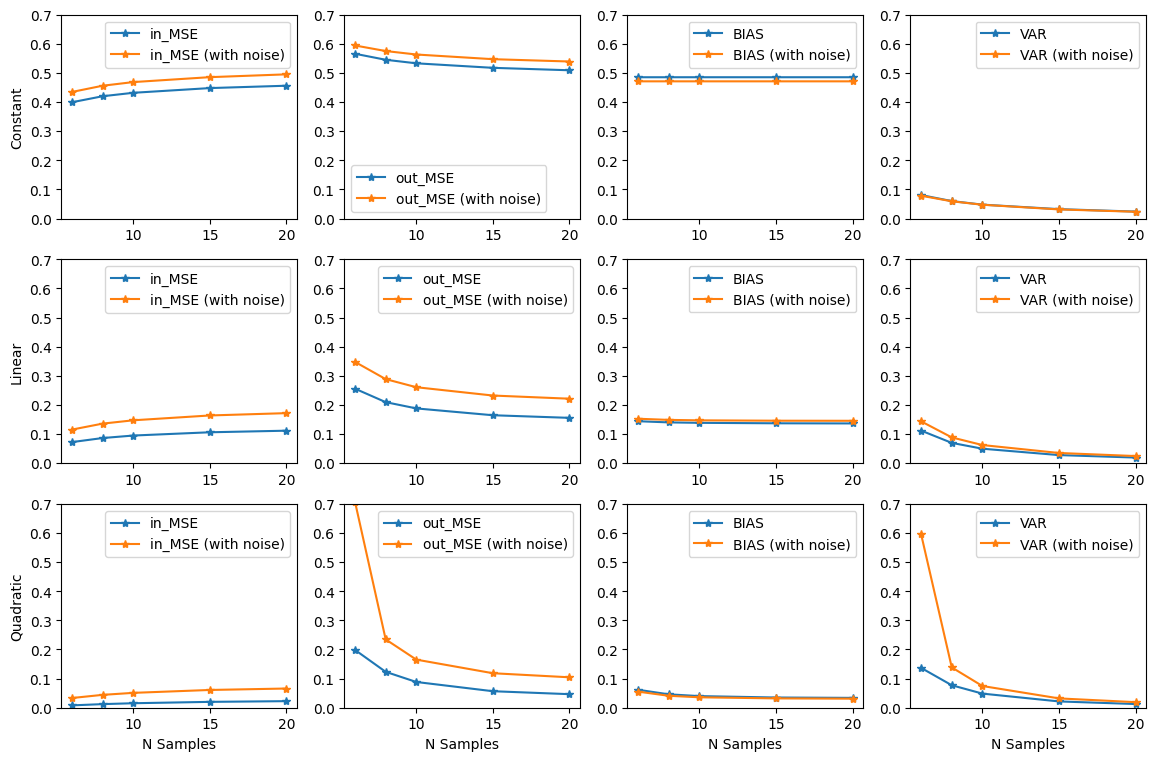

In [22]:
# Exercise #11 (continuation): generate plots to compare behaviors between averages MSEs, BIAS,
# and VAR for simulations in exercise #8 (no noise added) and exercise #11 (with noise added).

# add your code here...
tmp8 = e8.copy()
tmp8['idx'] = tmp8['Model Order'].astype(str)+tmp8['N Samples'].astype(str)
tmp11 = e11.copy()
tmp11['idx'] = tmp11['Model Order'].astype(str)+tmp11['N Samples'].astype(str)
noise_suffix = ' (with noise)'
plotdf = tmp11.set_index('idx').join(tmp8.set_index('idx'),how='inner',lsuffix=noise_suffix)

fig,ax = plt.subplots(3,4,figsize=(14,9))
cols = ['in_MSE','out_MSE','BIAS','VAR']
for n in range(3):
    for k,col in enumerate(cols):
        figttl = tags[n][0].upper()+tags[n][1:]+' Model: '+cols[k]
        tmp = plotdf[plotdf['Model Order']==n].set_index('N Samples')
        colstoplot = [col,col+noise_suffix]
        pid = tmp[colstoplot].plot(marker='*',ax=ax[n,k],ylim=(0,0.7))
        if n!=2: pid.set_xlabel('')
        if k==0: pid.set_ylabel(tags[n][0].upper()+tags[n][1:])
        
plt.show()